### Test

In [1]:
%matplotlib widget
import numpy as np
from matplotlib import pyplot as plt

# testing different grid generation methods. Oct 2023.

def grid_gen(xmin, xmax, mumin, mumax, nx, nmu, LOGSCALEX, DX1,X1LOW):
    # Generate polar coordinate arrays

    if(LOGSCALEX == 1):
        ii = np.linspace(0,nx-1,nx)
        x = np.exp(-X1LOW)*(np.exp(ii*DX1)-1.0)
    else:
        x = np.linspace(xmin,xmax,nx)
        
    mu = np.linspace(mumin,mumax,nmu)

    # Generate polar grid
    mu_grid, x_grid = np.meshgrid(mu, x)

    # Output
    return mu_grid, x_grid

XMIN = 0.0
XMAX = 50000
MUMIN = 0
MUMAX = 1
nr = 128
nth = 128
LOGSCALEX = 1
X1LOW = 8.0
X1 = np.log(np.exp(X1LOW)*XMAX + 1.0)
DX1 = X1/(nr - 1.0)

mugrid, xgrid = grid_gen(XMIN, XMAX, MUMIN, MUMAX, nr,nth,LOGSCALEX, DX1, X1LOW)
theta = 180/np.pi*np.arccos(mugrid)
xplot = np.copy(xgrid)
xplot[0,:] = 1.e-5
xlog = np.log10(xplot)
ii = np.linspace(0,nr-1,nr)
xx = np.exp(-X1LOW)*(np.exp(ii*DX1)-1.0)
if(LOGSCALEX == 1):
        dx = DX1
else:
    dx = (XMAX-XMIN)/(nr-1.0)
dmu = np.abs(MUMAX-MUMIN)/(nth-1.0)

<function matplotlib.pyplot.show(block=None)>

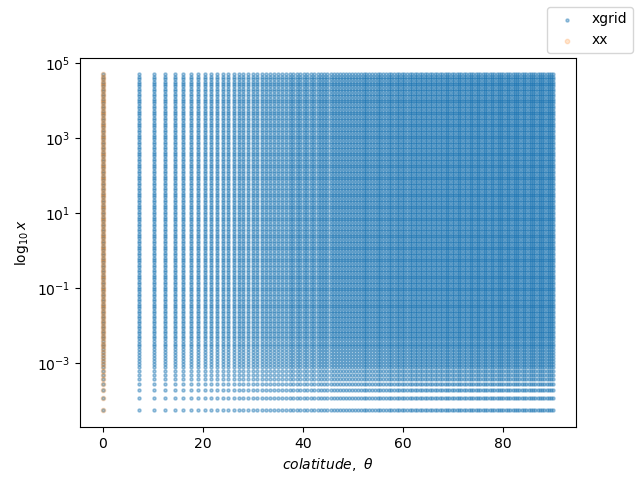

In [2]:
fig,ax = plt.subplots()
ax.scatter(theta, xgrid, s = 5, alpha = 0.4, label="xgrid")
ax.set(xlabel=r"$colatitude,~\theta$", ylabel=r"$\log_{10} x$", yscale="log")
ax.scatter(np.zeros_like(xx), xx, s = 10, label="xx", alpha = 0.2)
fig.legend()
plt.show


In [3]:
# x1 = np.log(xx + np.exp(-X1LOW)) + X1LOW
# x1limmin = 0
# x1limmax = 10
# xlimmin = 1.e-5
# xlimmax = 10
# fig,(ax,ax2) = plt.subplots(1,2, figsize = (12,5))
# ax.scatter(np.ones(np.shape(x1)),x1, s=15, alpha = 0.6)
# ax.set(ylabel=r"$\tilde{x}_1 = \log\left(\tilde{x} + e^{-L_x}\right) + L_x$", ylim=[x1limmin,x1limmax], title=f"$x_1 = [{x1limmin}, {x1limmax}]$")
# ax2.scatter(np.ones(np.shape(xx)),xx, s=15, alpha = 0.6)
# ax2.set(ylabel=r"$\tilde{x}$", title=f"$x = [{xlimmin}, {xlimmax}]$", yscale = "log", ylim = [xlimmin, xlimmax])
# # ax2.set(ylabel=r"$\tilde{x}$", title=f"$x = [{xlimmin}, {xlimmax}]$",ylim=[xlimmin, xlimmax])
# plt.show()

In [4]:
# fig,ax2 = plt.subplots()
# ax2.scatter(np.ones(np.shape(xx)),xx, s=15, alpha = 0.6)
# ax2.set(ylabel=r"$\tilde{x}$", title=f"$x = [{XMIN}, {XMAX}]$", yscale = "log")
# # ax2.set(ylabel=r"$\tilde{x}$", title=f"$x = [{xlimmin}, {xlimmax}]$",ylim=[xlimmin, xlimmax])
# plt.show()

**Conclusion**: increase the resolution near the stellar surface by choosing a larger value of `X1LOW`.

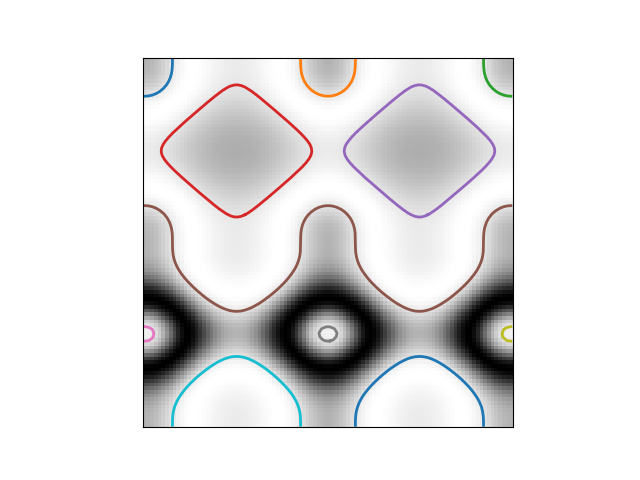

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import measure


# Construct some test data
x, y = np.ogrid[-np.pi : np.pi : 100j, -np.pi : np.pi : 100j]
r = np.sin(np.exp(np.sin(x) ** 3 + np.cos(y) ** 2))

# Find contours at a constant value of 0.8
contours = measure.find_contours(r, 0.8)

# Display the image and plot all contours found
fig, ax = plt.subplots()
ax.imshow(r, cmap=plt.cm.gray)

for contour in contours:
    ax.plot(contour[:, 1], contour[:, 0], linewidth=2)

ax.axis('image')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [6]:
def psi_gen(xgrid, mugrid,psi_star,psi_0, n_contours,aratio,dx,dmu,alpha):
        
    psi_grid = (psi_star/psi_0)*(1.0-mugrid*mugrid)/(xgrid/aratio+alpha)
    
    mu_levels = np.empty(n_contours)
    
    for i in range(n_contours):
        contour_mesh_value = (n_contours - i)/(n_contours+1.)/dmu
        mu_levels[i] = contour_mesh_value*dmu

    mu_levels_2 = np.linspace(mu_levels[0], mu_levels[-1], n_contours*10)
        
        
    psi_levels = (psi_star/psi_0)*(1-mu_levels*mu_levels)/alpha
    psi_levels_2 = (psi_star/psi_0)*(1-mu_levels_2*mu_levels_2)/alpha

    fig,ax = plt.subplots()
    ax.contour(np.arccos(mugrid[1:,:]), np.log10(xgrid[1:,:]), psi_grid[1:,:], levels=psi_levels,alpha = 0.2)
    # ax.contour(np.arccos(mugrid[1:,:]), np.log10(xgrid[1:,:]), psi_grid[1:,:], levels=psi_levels_2)
    plt.show()

    return psi_grid, psi_levels

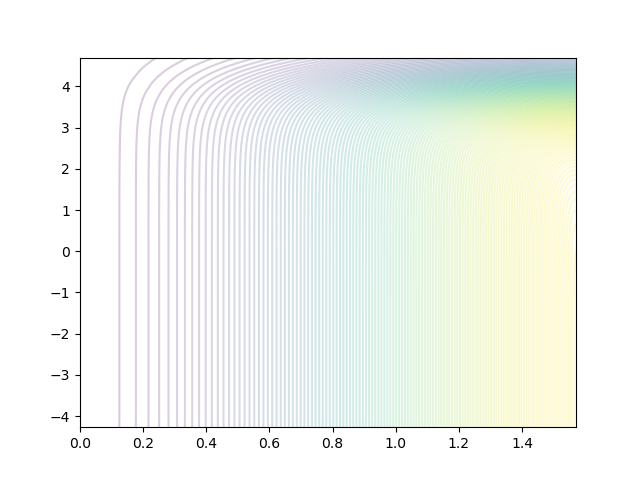

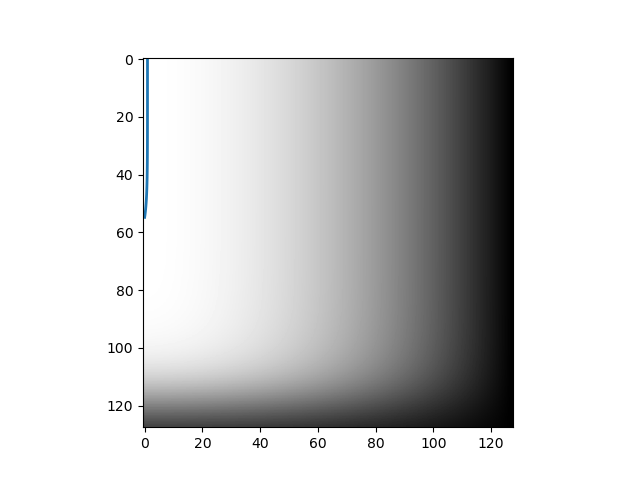

In [7]:
n_contours = nr - 1
R_star = 1e4
cs = 1e6
G = 6.6726e-11
M_sol = 1.989e30
M_star = 1.4*M_sol
x0 = (cs*R_star)**2/G/M_star
aratio = R_star/x0
alpha = 1.0
B_star = 1e8
psi_star = 0.5 * B_star * R_star**2
ma = 1e-7 * M_sol
psi_0 = np.sqrt(cs*cs * ma/x0**3)
psi_grid,psi_levels = psi_gen(xgrid,mugrid,psi_star,psi_0,n_contours,aratio,dx,dmu,alpha)

contours = measure.find_contours(psi_grid, psi_levels[-1])
fig, ax = plt.subplots()
ax.imshow(psi_grid, cmap=plt.cm.gray)

for contour in contours:
    ax.plot(contour[:, 1], contour[:, 0], linewidth=2)

In [12]:
XMAX = 50000
X1LOW = 8
X1 = np.log(np.exp(X1LOW)*XMAX + 1)
X1LOW2 = 0
X1_2 = np.log(np.exp(X1LOW2)*XMAX + 1)
DX1 = X1/127
DX1_2 = X1_2/127
ii = np.linspace(0,127,128)
x = np.exp(-X1LOW)*(np.exp(ii*DX1) - 1)
x_2 = np.exp(-X1LOW2)*(np.exp(ii*DX1_2) - 1)

print(x[1], x[-1],x_2[1], x_2[-1])

5.3583449925273604e-05 50000.00000000006 0.08892967261406604 50000.000000000015
